In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib as plt

In [2]:
df= pd.read_csv('customer_conversion.csv')
print(df.head())
print(df.describe())
print(df['converted'].value_counts())

   age  monthly_income  browsing_time  previous_purchases  \
0   56    11406.031379      25.080266                   6   
1   46    44216.926400      16.033711                   4   
2   32    69956.578449      44.385425                   7   
3   25    79989.758094      32.098181                   4   
4   38    60771.478224      51.737384                   4   

   discount_sensitivity  location_score  engagement_score  converted  
0              0.256681               6         63.093993          0  
1              0.713901               6         86.392892          0  
2              0.480019               3         57.205026          0  
3              0.402394               3         45.786101          0  
4              0.151458               3         47.581471          0  
               age  monthly_income  browsing_time  previous_purchases  \
count  1000.000000     1000.000000    1000.000000         1000.000000   
mean     38.745000    50130.956346      30.721701            

In [3]:
X= df.drop("converted", axis=1)
y= df['converted']

X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42)
model= DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred= model.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.98      0.99      0.98       195
           1       0.33      0.20      0.25         5

    accuracy                           0.97       200
   macro avg       0.66      0.59      0.62       200
weighted avg       0.96      0.97      0.97       200



In [4]:
for dept in [None, 3, 10]:
    temp_model= DecisionTreeClassifier(max_depth= dept, random_state=42)
    temp_model.fit(X_train, y_train)
    print("Depth:",dept, 
          "Train Accuracy:", temp_model.score(X_train, y_train),
          "Tset Accuracy:", temp_model.score(X_test, y_test)
          )

param_grid={
    "max_depth": [None, 3,5,10],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,4],
    "criterion": ["gini","entropy"]
}
grid= GridSearchCV(DecisionTreeClassifier(random_state=42),
                   param_grid,
                   cv=5,
                   scoring="f1")

grid.fit(X_train, y_train)
print("Best Parameters:", grid.best_params_)
print("Best CV score:", grid.best_score_)
importances= grid.best_estimator_.feature_importances_
features_name=X.columns
importance_df=pd.DataFrame({"Feature":features_name, "Importance":importances})
print(importance_df.sort_values(by="Importance", ascending=False))

Depth: None Train Accuracy: 1.0 Tset Accuracy: 0.97
Depth: 3 Train Accuracy: 0.99625 Tset Accuracy: 0.98
Depth: 10 Train Accuracy: 1.0 Tset Accuracy: 0.97
Best Parameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV score: 0.0
                Feature  Importance
6      engagement_score    0.519178
1        monthly_income    0.321798
4  discount_sensitivity    0.100629
0                   age    0.037335
3    previous_purchases    0.021060
2         browsing_time    0.000000
5        location_score    0.000000


Epoch 1/100


c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8141 - loss: 0.5157 - val_accuracy: 1.0000 - val_loss: 0.3165
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9891 - loss: 0.2485 - val_accuracy: 1.0000 - val_loss: 0.1523
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9922 - loss: 0.1448 - val_accuracy: 1.0000 - val_loss: 0.0831
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9922 - loss: 0.1150 - val_accuracy: 1.0000 - val_loss: 0.0548
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9922 - loss: 0.0896 - val_accuracy: 1.0000 - val_loss: 0.0405
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9922 - loss: 0.0749 - val_accuracy: 1.0000 - val_loss: 0.0333
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9922 - loss: 0.0791 - val_accuracy: 1.0000 - val_loss: 0.0290
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9922 - loss: 0.0686 - val_accuracy: 1.0000 - val_loss: 0.

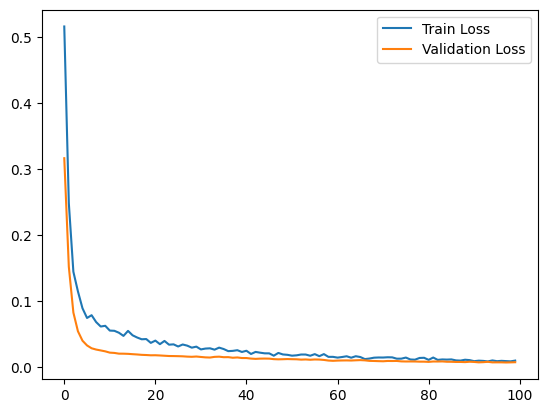

In [5]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Build model function
def build_model(neurons=64, dropout_rate=0.3, learning_rate=0.001):

    model = keras.Sequential([
        layers.Dense(neurons,
                     activation="relu",
                     kernel_regularizer=regularizers.l2(0.001),
                     input_shape=(X_train.shape[1],)),
        layers.Dropout(dropout_rate),
        layers.Dense(neurons//2, activation="relu"),
        layers.Dropout(dropout_rate),
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

model = build_model()

history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)]
)

# Evaluate
loss, acc = model.evaluate(X_test_scaled, y_test)
print("Test Accuracy:", acc)

# Plot loss curves
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.legend(["Train Loss", "Validation Loss"])
plt.show()


In [6]:
import optuna

def objective(trial):

    neurons = trial.suggest_int("neurons", 32, 256)
    dropout = trial.suggest_float("dropout", 0.1, 0.5)
    lr = trial.suggest_float("learning_rate", 1e-5, 1e-1, log=True)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])

    model = build_model(
        neurons=neurons,
        dropout_rate=dropout,
        learning_rate=lr
    )

    history = model.fit(
        X_train_scaled, y_train,
        validation_split=0.2,
        epochs=50,
        batch_size=batch_size,
        verbose=0
    )

    val_acc = max(history.history["val_accuracy"])
    return val_acc


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

print("Best Trial:", study.best_params)

c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-02-28 09:44:51,103] A new study created in memory with name: no-name-ddb0f5cd-c9aa-4268-a822-10b1d8667a31
c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
[I 2026-02-28 09:45:00,520] Trial 0 finished with value: 1.0 and parameters: {'neurons': 127, 'dropout': 0.19865728962161977, 'learning_rate': 0.002880956949657032, 'batch_size': 16}. Best is trial 0 with value: 1.0.
[I 2026-02-28 09:45:07,468] 

Best Trial: {'neurons': 127, 'dropout': 0.19865728962161977, 'learning_rate': 0.002880956949657032, 'batch_size': 16}
